  NSE — Graham + Peter Lynch + UTBot
  Long  : UTBot BUY  + Graham undervalued + PEG < 1.0
  Short : UTBot SELL + Graham overvalued  + PEG > 2.0

Total tickers: 2224

Fetching 2224 tickers (20 workers)...

  [200/2224]  loaded: 137  |  ETA: 1.2 min


HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"User is unable to access this feature - https://bit.ly/yahoo-finance-api-feedback"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"User is unable to access this feature - https://bit.ly/yahoo-finance-api-feedback"}}}


  [400/2224]  loaded: 276  |  ETA: 0.8 min


HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
HTTP Error 401: {"finance":{"result":null,"err

  [600/2224]  loaded: 424  |  ETA: 0.7 min
  [800/2224]  loaded: 570  |  ETA: 0.6 min
  [1000/2224]  loaded: 732  |  ETA: 0.4 min


...

  [1400/2224]  loaded: 1003  |  ETA: 0.3 min
  [1600/2224]  loaded: 1152  |  ETA: 0.2 min
  [1800/2224]  loaded: 1283  |  ETA: 0.2 min


HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}


  [2000/2224]  loaded: 1432  |  ETA: 0.1 min
  [2200/2224]  loaded: 1562  |  ETA: 0.0 min
  [2224/2224]  loaded: 1574  |  ETA: 0.0 min

Loaded 1574 stocks in 0.8 min

Backtesting over 2472 trading days...


  RESULTS — Graham + Lynch + UTBot


C:\Users\USER\AppData\Local\Temp\ipykernel_3132\13052117.py:499: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ret_s  = pd.Series(eq).pct_change().dropna()


  Period         : 2016-05-12 → 2026-05-13
  Initial Capital: ₹100,000
  Final Capital  : ₹209,746
  Total Return   : 109.7%
  CAGR           : 7.7%
  Max Drawdown   : nan%
  Sharpe Ratio   : 0.44
  Total Trades   : 3591
  Win Rate       : 32.5%
  Avg Win        : ₹4,189
  Avg Loss       : ₹-1,735
  Risk/Reward    : 2.41
  Avg Hold (days): 4

  By Trade Type:
    LONG: 3585 trades | win rate: 32.5% | avg profit: ₹207
    SHORT: 6 trades | win rate: 16.7% | avg profit: ₹-3,106

  Exit Reasons:
    Long ATR Stop          3422 trades | avg: 0.5%
    Long Stop               146 trades | avg: -5.5%
    UTBot Sell               17 trades | avg: 2.0%
    UTBot Buy Cover           6 trades | avg: -2.5%

  Graham Signal Stats:
    Avg Graham Value (Longs) : ₹3,992.9
    Avg PEG at Short Entry   : 1185.48
Saved: trade_log_gl.xlsx
Chart saved: backtest_gl.png


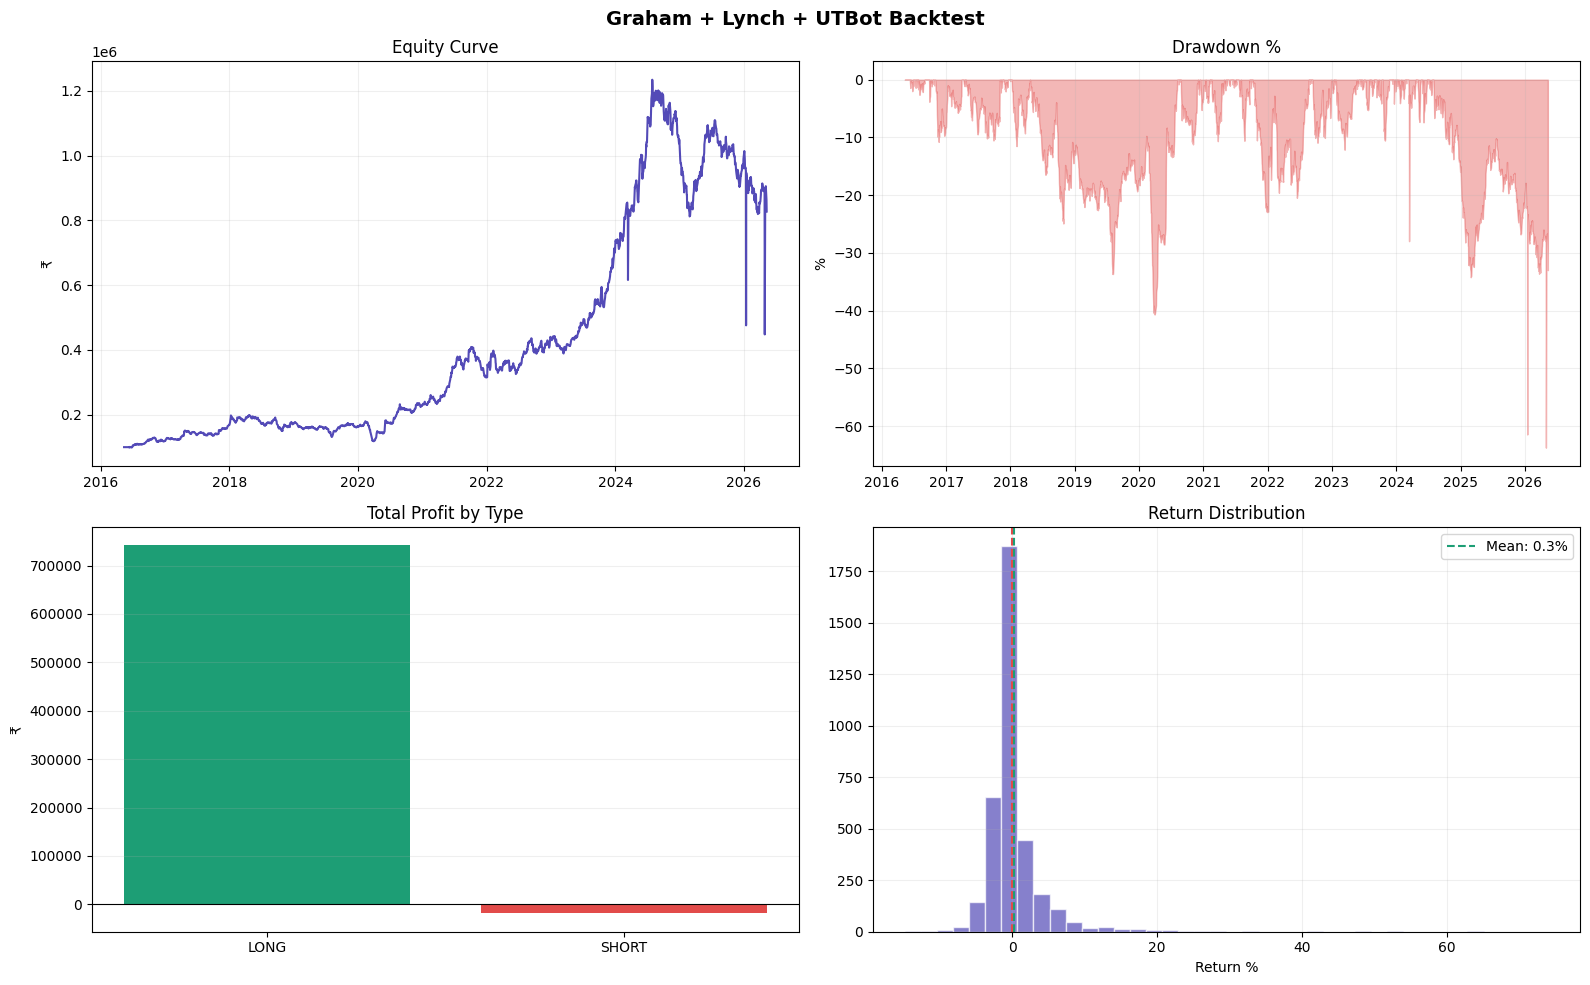

In [1]:
"""
=============================================================
  NSE BACKTEST — Graham + Peter Lynch + UTBot
  ─────────────────────────────────────────────────────────
  LONG ENTRY  (ALL 3 must be true):
    1. UTBot BUY signal
    2. Graham: Price < Intrinsic Value          (undervalued)
    3. Lynch:  PEG Ratio < 1                   (undervalued)

  SHORT ENTRY  (ALL 3 must be true):
    1. UTBot SELL signal
    2. Graham: Price > Intrinsic Value × 1.5   (overvalued)
    3. Lynch:  PEG Ratio > 2                   (overvalued)

  LONG EXIT:
    • Hard stop loss
    • ATR trailing stop
    • Max drawdown
    • UTBot SELL signal

  SHORT EXIT:
    • UTBot BUY signal (cover)
    • Short stop loss (price rises X% above entry)
=============================================================
"""

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
import time
from concurrent.futures import ThreadPoolExecutor, as_completed

# ─────────────────────────────────────────────
#  SETTINGS
# ─────────────────────────────────────────────
INITIAL_CAPITAL      = 100_000
STOP_LOSS_PCT        = 0.04       # long hard stop
SHORT_STOP_LOSS_PCT  = 0.09       # short hard stop (price rises 5% above entry)
MAX_POSITIONS        = 4   # combined long + short slots
LOOKBACK_PERIOD      = "10y"
ATR_PERIOD           = 14
ATR_MULTIPLIER       = 0.2
MAX_DRAWDOWN_PCT     = 0.04

MIN_MARKET_CAP_CR    = 500        # crore INR

# Graham thresholds
GRAHAM_OVERVALUE_MULT = 1.5       # short if price > intrinsic × 1.5
GRAHAM_GROWTH_CAP     = 12.0      # cap g at 12% in formula

# Lynch / PEG thresholds
PEG_BUY_THRESHOLD    = 1.0        # long  if PEG < 1
PEG_SHORT_THRESHOLD  = 2.0        # short if PEG > 2

MAX_WORKERS          = 20
CACHE_DIR            = "cache_gl"
USE_CACHE            = True

os.makedirs(CACHE_DIR, exist_ok=True)

# ─────────────────────────────────────────────
#  CACHE
# ─────────────────────────────────────────────
def cache_path(ticker):
    return os.path.join(CACHE_DIR, ticker.replace(".", "_") + ".pkl")

def load_from_cache(ticker):
    p = cache_path(ticker)
    if USE_CACHE and os.path.exists(p):
        try:
            with open(p, "rb") as f:
                return pickle.load(f)
        except:
            pass
    return None

def save_to_cache(ticker, data):
    try:
        with open(cache_path(ticker), "wb") as f:
            pickle.dump(data, f)
    except:
        pass

# ─────────────────────────────────────────────
#  TIMEZONE FIX
# ─────────────────────────────────────────────
def normalize_index(df):
    idx = df.index
    if hasattr(idx, "tz") and idx.tz is not None:
        idx = idx.tz_convert("UTC").tz_localize(None)
    df.index = idx.normalize()
    return df

# ─────────────────────────────────────────────
#  LOAD NSE TICKERS
# ─────────────────────────────────────────────
def load_nse_tickers():
    df      = pd.read_csv("data/EQUITY_L.csv")
    symbols = df["SYMBOL"].dropna().astype(str).str.strip().unique().tolist()
    return [s + ".NS" for s in symbols if "&" not in s]

# ─────────────────────────────────────────────
#  UT BOT
# ─────────────────────────────────────────────
def compute_utbot(df):
    df    = df.copy()
    close = df["Close"]
    high  = df["High"]
    low   = df["Low"]

    tr = np.maximum(
        high - low,
        np.maximum(
            (high - close.shift()).abs(),
            (low  - close.shift()).abs()
        )
    )

    df["atr"]   = tr.rolling(ATR_PERIOD).mean()
    df["upper"] = close - ATR_MULTIPLIER * df["atr"]
    df["lower"] = close + ATR_MULTIPLIER * df["atr"]

    trend = [1]
    for i in range(1, len(df)):
        if   close.iloc[i] > df["lower"].iloc[i-1]: trend.append(1)
        elif close.iloc[i] < df["upper"].iloc[i-1]: trend.append(-1)
        else:                                        trend.append(trend[-1])

    df["trend"]      = trend
    df["buy"]        = (df["trend"] == 1)  & (df["trend"].shift() == -1)
    df["sell"]       = (df["trend"] == -1) & (df["trend"].shift() == 1)
    df["volatility"] = close.pct_change(fill_method=None).rolling(20).std()
    return df

# ─────────────────────────────────────────────
#  GRAHAM FORMULA
#  Intrinsic = EPS × (8.5 + 2g)
#  g capped at GRAHAM_GROWTH_CAP %
# ─────────────────────────────────────────────
def graham_intrinsic(eps, growth_pct):
    if eps is None or eps <= 0:
        return None
    g = min(growth_pct, GRAHAM_GROWTH_CAP)
    return max(eps * (8.5 + 2 * g), 0)

def graham_signal(price, intrinsic):
    """
    Returns:
      'undervalued'  → price < intrinsic           → candidate for LONG
      'overvalued'   → price > intrinsic × 1.5     → candidate for SHORT
      'neutral'      → everything else
    """
    if intrinsic is None or intrinsic <= 0:
        return "neutral"
    if price < intrinsic:
        return "undervalued"
    if price > intrinsic * GRAHAM_OVERVALUE_MULT:
        return "overvalued"
    return "neutral"

# ─────────────────────────────────────────────
#  PETER LYNCH — PEG RATIO
#  PEG = (P/E) / EPS Growth Rate (%)
#
#  Lynch Rule:
#    PEG < 1  → undervalued (fast grower cheap)
#    PEG > 2  → overvalued  (slow grower expensive)
#    1–2      → fairly valued
# ─────────────────────────────────────────────
def peg_ratio(price, eps, growth_pct):
    """
    price      — current stock price
    eps        — trailing twelve months EPS
    growth_pct — earnings growth rate in % (e.g. 15 for 15%)
    Returns PEG ratio or None if not calculable.
    """
    if eps is None or eps <= 0:
        return None
    if growth_pct is None or growth_pct <= 0:
        return None
    pe = price / eps
    if pe <= 0:
        return None
    return pe / growth_pct

def lynch_signal(peg):
    """
    Returns:
      'undervalued' → PEG < PEG_BUY_THRESHOLD   (1.0)
      'overvalued'  → PEG > PEG_SHORT_THRESHOLD  (2.0)
      'neutral'     → everything else
    """
    if peg is None:
        return "neutral"
    if peg < PEG_BUY_THRESHOLD:
        return "undervalued"
    if peg > PEG_SHORT_THRESHOLD:
        return "overvalued"
    return "neutral"

# ─────────────────────────────────────────────
#  FETCH TICKER
# ─────────────────────────────────────────────
def fetch_ticker(ticker):
    cached = load_from_cache(ticker)
    if cached is not None:
        return ticker, cached

    try:
        stock = yf.Ticker(ticker)
        info  = stock.info

        # Market cap filter
        mc = info.get("marketCap")
        if not mc or mc / 1e7 < MIN_MARKET_CAP_CR:
            return ticker, None

        # EPS (required for both formulas)
        eps = info.get("trailingEps")
        if eps is None:
            return ticker, None

        # Growth rate — try multiple fields
        growth_raw = (
            info.get("earningsQuarterlyGrowth") or
            info.get("earningsGrowth")          or
            info.get("revenueGrowth")           or
            0.08   # default 8% if not available
        )
        growth_pct = abs(growth_raw) * 100   # convert 0.15 → 15.0

        # Price history
        df = stock.history(period=LOOKBACK_PERIOD)
        if df.empty or len(df) < 60:
            return ticker, None

        df = compute_utbot(df)
        df = normalize_index(df)

        # Precompute Graham intrinsic (fixed, based on current EPS & growth)
        intrinsic = graham_intrinsic(eps, growth_pct)

        # Attach valuation columns
        df["EPS"]           = eps
        df["GrowthPct"]     = growth_pct
        df["GrahamValue"]   = intrinsic if intrinsic else np.nan
        df["MarketCapCr"]   = mc / 1e7

        # PEG ratio is price-dependent → computed per bar in backtest
        # But we store EPS + growth so we can compute it daily
        # (PEG = (Price/EPS) / GrowthPct)

        save_to_cache(ticker, df)
        return ticker, df

    except:
        return ticker, None

# ─────────────────────────────────────────────
#  LOAD ALL DATA
# ─────────────────────────────────────────────
def load_all_data(tickers):
    all_data = {}
    print(f"\nFetching {len(tickers)} tickers ({MAX_WORKERS} workers)...\n")
    t0 = time.time()

    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
        futures = {ex.submit(fetch_ticker, t): t for t in tickers}
        done    = 0
        for fut in as_completed(futures):
            ticker, df = fut.result()
            done += 1
            if df is not None:
                all_data[ticker] = df
            if done % 200 == 0 or done == len(tickers):
                eta = ((time.time()-t0)/done) * (len(tickers)-done)
                print(f"  [{done}/{len(tickers)}]  "
                      f"loaded: {len(all_data)}  |  "
                      f"ETA: {eta/60:.1f} min")

    print(f"\nLoaded {len(all_data)} stocks in "
          f"{(time.time()-t0)/60:.1f} min\n")
    return all_data

# ─────────────────────────────────────────────
#  BACKTEST
# ─────────────────────────────────────────────
def run_backtest(all_data):
    cash           = float(INITIAL_CAPITAL)
    open_positions = {}
    trade_log      = []
    equity_curve   = []
    date_index     = []

    # Normalize all indices
    for ticker in list(all_data.keys()):
        all_data[ticker] = normalize_index(all_data[ticker])

    all_dates = sorted(set(
        d for df in all_data.values() for d in df.index
    ))
    print(f"Backtesting over {len(all_dates)} trading days...\n")

    for current_date in all_dates:

        # ── EXIT POSITIONS ────────────────────
        for ticker in list(open_positions.keys()):
            df  = all_data[ticker]
            if current_date not in df.index:
                continue

            row  = df.loc[current_date]
            pos  = open_positions[ticker]
            typ  = pos["type"]
            exit_reason = None
            exit_price  = None
            profit      = 0.0

            # ── LONG EXIT ─────────────────────
            if typ == "LONG":
                pos["highest"] = max(pos["highest"], float(row["Close"]))

                stop_p  = pos["entry"] * (1 - STOP_LOSS_PCT)
                atr_stp = pos["highest"] - float(row["atr"]) * ATR_MULTIPLIER
                dd      = (pos["highest"] - float(row["Close"])) / pos["highest"]

                if   float(row["Close"]) <= stop_p:  exit_reason = "Long Stop"
                elif float(row["Close"]) <= atr_stp: exit_reason = "Long ATR Stop"
                elif dd >= MAX_DRAWDOWN_PCT:          exit_reason = "Long Max DD"
                elif bool(row["sell"]):              exit_reason = "UTBot Sell"

                if exit_reason:
                    exit_price = float(row["Close"])
                    proceeds   = pos["shares"] * exit_price
                    profit     = proceeds - pos["invested"]
                    cash      += proceeds

            # ── SHORT EXIT ────────────────────
            else:
                short_stop = pos["entry"] * (1 + SHORT_STOP_LOSS_PCT)

                if   float(row["Close"]) >= short_stop: exit_reason = "Short Stop"
                elif bool(row["buy"]):                  exit_reason = "UTBot Buy Cover"

                if exit_reason:
                    exit_price = float(row["Close"])
                    profit     = (pos["entry"] - exit_price) * pos["shares"]
                    cash      += pos["invested"] + profit

            # ── LOG ───────────────────────────
            if exit_reason and exit_price is not None:
                ret = (
                    (pos["entry"] - exit_price) / pos["entry"] * 100
                    if typ == "SHORT"
                    else (exit_price / pos["entry"] - 1) * 100
                )
                trade_log.append({
                    "Stock":        ticker,
                    "Type":         typ,
                    "Entry Date":   pos["entry_date"],
                    "Exit Date":    current_date,
                    "Entry Price":  round(pos["entry"], 2),
                    "Exit Price":   round(exit_price, 2),
                    "Shares":       round(pos["shares"], 4),
                    "Invested":     round(pos["invested"], 2),
                    "Profit":       round(profit, 2),
                    "Return %":     round(ret, 2),
                    "Exit Reason":  exit_reason,
                    "Graham Value": round(float(row["GrahamValue"]), 2)
                                    if not pd.isna(row["GrahamValue"]) else None,
                    "PEG at Entry": round(pos["peg_at_entry"], 3)
                                    if pos["peg_at_entry"] else None,
                    "Market Cap Cr": round(float(row["MarketCapCr"]), 1),
                    "Holding Days": (current_date - pos["entry_date"]).days,
                })
                del open_positions[ticker]

        # ── ENTRY ─────────────────────────────
        slots = MAX_POSITIONS - len(open_positions)

        if slots > 0 and cash > 0:
            long_candidates  = []
            short_candidates = []

            for ticker, df in all_data.items():
                if ticker in open_positions:
                    continue
                if current_date not in df.index:
                    continue

                row = df.loc[current_date]

                if pd.isna(row["volatility"]) or row["volatility"] == 0:
                    continue

                price      = float(row["Close"])
                eps        = float(row["EPS"])
                growth_pct = float(row["GrowthPct"])
                intrinsic  = float(row["GrahamValue"]) if not pd.isna(row["GrahamValue"]) else None

                # Compute live PEG ratio for this bar's price
                peg = peg_ratio(price, eps, growth_pct)

                # Valuation signals
                g_sig = graham_signal(price, intrinsic)
                l_sig = lynch_signal(peg)

                # ── LONG: UTBot buy + both say undervalued ──
                if (
                    bool(row["buy"])
                    and g_sig == "undervalued"
                    and l_sig == "undervalued"
                ):
                    # Score: deeper discount + lower PEG = higher rank
                    graham_disc = (intrinsic - price) / intrinsic if intrinsic else 0
                    peg_disc    = (PEG_BUY_THRESHOLD - peg) if peg else 0
                    score       = (graham_disc + peg_disc) / row["volatility"]
                    long_candidates.append((ticker, score, peg, row))

                # ── SHORT: UTBot sell + both say overvalued ──
                elif (
                    bool(row["sell"])
                    and g_sig == "overvalued"
                    and l_sig == "overvalued"
                ):
                    # Score: more overvalued = higher priority short
                    graham_over = (price / intrinsic) if intrinsic else 1
                    peg_over    = peg if peg else PEG_SHORT_THRESHOLD
                    score       = (graham_over + peg_over) / row["volatility"]
                    short_candidates.append((ticker, score, peg, row))

            # Sort both lists by score descending
            long_candidates.sort(key=lambda x: x[1],  reverse=True)
            short_candidates.sort(key=lambda x: x[1], reverse=True)

            # Allocate: prioritize longs, fill remaining with shorts
            all_candidates = long_candidates + short_candidates

            for ticker, score, peg, row in all_candidates[:slots]:
                remaining = MAX_POSITIONS - len(open_positions)
                if remaining <= 0 or cash <= 0:
                    break

                typ        = "LONG" if (ticker, score, peg, row) in [(t,s,p,r) for t,s,p,r in long_candidates] else "SHORT"
                allocation = cash / remaining
                price      = float(row["Close"])
                shares     = allocation / price
                cash      -= allocation

                open_positions[ticker] = {
                    "type":         typ,
                    "entry_date":   current_date,
                    "entry":        price,
                    "highest":      price,
                    "shares":       shares,
                    "invested":     allocation,
                    "peg_at_entry": peg,
                }

        # ── DAILY EQUITY ──────────────────────
        pv = cash
        for ticker, pos in open_positions.items():
            df = all_data[ticker]
            if current_date not in df.index:
                continue
            price = float(df.loc[current_date]["Close"])
            if pos["type"] == "LONG":
                pv += pos["shares"] * price
            else:
                unrealized = (pos["entry"] - price) * pos["shares"]
                pv += pos["invested"] + unrealized

        equity_curve.append(pv)
        date_index.append(current_date)

    return pd.DataFrame(trade_log), equity_curve, date_index

# ─────────────────────────────────────────────
#  METRICS
# ─────────────────────────────────────────────
def print_summary(trades, equity_curve, date_index):
    print("\n" + "="*55)
    print("  RESULTS — Graham + Lynch + UTBot")
    print("="*55)

    if not equity_curve:
        print("  ERROR: equity_curve empty.")
        return

    eq     = np.array(equity_curve)
    final  = eq[-1]
    years  = (date_index[-1] - date_index[0]).days / 365.25
    cagr   = ((final / INITIAL_CAPITAL) ** (1/years) - 1) * 100 if years > 0 else 0
    peak   = np.maximum.accumulate(eq)
    mdd    = ((eq - peak) / peak).min() * 100
    ret_s  = pd.Series(eq).pct_change().dropna()
    sharpe = (ret_s.mean() / ret_s.std() * np.sqrt(252)) if ret_s.std() > 0 else 0

    print(f"  Period         : {date_index[0].date()} → {date_index[-1].date()}")
    print(f"  Initial Capital: ₹{INITIAL_CAPITAL:,.0f}")
    print(f"  Final Capital  : ₹{final:,.0f}")
    print(f"  Total Return   : {(final/INITIAL_CAPITAL-1)*100:.1f}%")
    print(f"  CAGR           : {cagr:.1f}%")
    print(f"  Max Drawdown   : {mdd:.1f}%")
    print(f"  Sharpe Ratio   : {sharpe:.2f}")
    print(f"  Total Trades   : {len(trades)}")

    if not trades.empty:
        wins     = trades[trades["Profit"] > 0]
        losses   = trades[trades["Profit"] < 0]
        win_rate = len(wins) / len(trades) * 100
        avg_win  = wins["Profit"].mean()   if len(wins)   > 0 else 0
        avg_loss = losses["Profit"].mean() if len(losses) > 0 else 0
        rr       = abs(avg_win/avg_loss)   if avg_loss    != 0 else 0

        print(f"  Win Rate       : {win_rate:.1f}%")
        print(f"  Avg Win        : ₹{avg_win:,.0f}")
        print(f"  Avg Loss       : ₹{avg_loss:,.0f}")
        print(f"  Risk/Reward    : {rr:.2f}")
        print(f"  Avg Hold (days): {trades['Holding Days'].mean():.0f}")

        print("\n  By Trade Type:")
        for typ in ["LONG", "SHORT"]:
            t = trades[trades["Type"] == typ]
            if len(t) == 0: continue
            wr = len(t[t["Profit"]>0]) / len(t) * 100
            print(f"    {typ}: {len(t)} trades | "
                  f"win rate: {wr:.1f}% | "
                  f"avg profit: ₹{t['Profit'].mean():,.0f}")

        print("\n  Exit Reasons:")
        for reason, cnt in trades["Exit Reason"].value_counts().items():
            avg_r = trades[trades["Exit Reason"]==reason]["Return %"].mean()
            print(f"    {reason:<22} {cnt:>4} trades | avg: {avg_r:.1f}%")

        print("\n  Graham Signal Stats:")
        longs  = trades[trades["Type"]=="LONG"]
        shorts = trades[trades["Type"]=="SHORT"]
        if not longs.empty and "Graham Value" in longs.columns:
            print(f"    Avg Graham Value (Longs) : ₹{longs['Graham Value'].mean():,.1f}")
        if not shorts.empty and "PEG at Entry" in shorts.columns:
            print(f"    Avg PEG at Short Entry   : {shorts['PEG at Entry'].mean():.2f}")

    print("="*55)

# ─────────────────────────────────────────────
#  SAVE EXCEL
# ─────────────────────────────────────────────
def save_excel(trades):
    if trades.empty:
        print("No trades to save.")
        return

    trades = trades.sort_values("Exit Date").copy()
    trades["Cumulative Profit"] = trades["Profit"].cumsum()
    trades["Equity"]            = INITIAL_CAPITAL + trades["Cumulative Profit"]

    # Strip timezone (Excel fix)
    for col in ["Entry Date", "Exit Date"]:
        if col in trades.columns:
            trades[col] = pd.to_datetime(trades[col])
            if trades[col].dt.tz is not None:
                trades[col] = trades[col].dt.tz_localize(None)

    with pd.ExcelWriter("trade_log_gl.xlsx", engine="openpyxl") as writer:
        trades.to_excel(writer, sheet_name="All Trades", index=False)
        trades[trades["Type"]=="LONG"].to_excel(writer, sheet_name="Long Trades", index=False)
        trades[trades["Type"]=="SHORT"].to_excel(writer, sheet_name="Short Trades", index=False)

        summary = pd.DataFrame({
            "Metric": ["Total Trades","Long Trades","Short Trades",
                       "Win Rate %","Avg Win ₹","Avg Loss ₹"],
            "Value": [
                len(trades),
                len(trades[trades["Type"]=="LONG"]),
                len(trades[trades["Type"]=="SHORT"]),
                round(len(trades[trades["Profit"]>0])/len(trades)*100, 2),
                round(trades[trades["Profit"]>0]["Profit"].mean(), 2),
                round(trades[trades["Profit"]<0]["Profit"].mean(), 2),
            ]
        })
        summary.to_excel(writer, sheet_name="Summary", index=False)

    print("Saved: trade_log_gl.xlsx")

# ─────────────────────────────────────────────
#  PLOT
# ─────────────────────────────────────────────
def plot(equity_curve, date_index, trades):
    if not equity_curve:
        return

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle("Graham + Lynch + UTBot Backtest", fontsize=14, fontweight="bold")

    # 1. Equity curve
    ax = axes[0, 0]
    ax.plot(date_index, equity_curve, color="#534AB7", lw=1.5)
    ax.set_title("Equity Curve"); ax.set_ylabel("₹"); ax.grid(alpha=0.2)

    # 2. Drawdown
    ax = axes[0, 1]
    eq   = np.array(equity_curve)
    peak = np.maximum.accumulate(eq)
    dd   = (eq - peak) / peak * 100
    ax.fill_between(date_index, dd, 0, color="#E24B4A", alpha=0.4)
    ax.set_title("Drawdown %"); ax.set_ylabel("%"); ax.grid(alpha=0.2)

    if not trades.empty:
        # 3. Long vs Short profit
        ax = axes[1, 0]
        typ_profit = trades.groupby("Type")["Profit"].sum()
        colors     = ["#1D9E75" if v >= 0 else "#E24B4A" for v in typ_profit.values]
        ax.bar(typ_profit.index, typ_profit.values, color=colors)
        ax.set_title("Total Profit by Type"); ax.set_ylabel("₹"); ax.grid(alpha=0.2, axis="y")
        ax.axhline(0, color="black", lw=0.8)

        # 4. Return distribution
        ax = axes[1, 1]
        ax.hist(trades["Return %"], bins=40, color="#534AB7", alpha=0.7, edgecolor="white")
        ax.axvline(0, color="#E24B4A", lw=1.5, linestyle="--")
        ax.axvline(trades["Return %"].mean(), color="#1D9E75", lw=1.5,
                   linestyle="--", label=f'Mean: {trades["Return %"].mean():.1f}%')
        ax.set_title("Return Distribution"); ax.set_xlabel("Return %")
        ax.legend(); ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.savefig("backtest_gl.png", dpi=150, bbox_inches="tight")
    print("Chart saved: backtest_gl.png")
    plt.show()

# ─────────────────────────────────────────────
#  MAIN
# ─────────────────────────────────────────────
if __name__ == "__main__":
    print("=" * 55)
    print("  NSE — Graham + Peter Lynch + UTBot")
    print(f"  Long  : UTBot BUY  + Graham undervalued + PEG < {PEG_BUY_THRESHOLD}")
    print(f"  Short : UTBot SELL + Graham overvalued  + PEG > {PEG_SHORT_THRESHOLD}")
    print("=" * 55)

    tickers  = load_nse_tickers()
    print(f"\nTotal tickers: {len(tickers)}")

    all_data = load_all_data(tickers)

    if not all_data:
        print("ERROR: No data loaded.")
        exit(1)

    trades, equity_curve, date_index = run_backtest(all_data)

    print_summary(trades, equity_curve, date_index)
    save_excel(trades)
    plot(equity_curve, date_index, trades)
